# Intraday Liquidity Calculation

This notebook walks through the end-to-end pipeline for monitoring intraday liquidity:
1. Load and inspect payment transaction data
2. Clean and preprocess the data
3. Compute intraday time buckets
4. Calculate the running liquidity position
5. Visualize the intraday liquidity position

## Step 1 — Load Data

In [1]:
import pandas as pd
import numpy as np

# Simulate intraday payment transaction data
np.random.seed(42)
n = 200

timestamps = pd.date_range('2024-01-15 08:00', periods=n, freq='3min')

transactions = pd.DataFrame({
    'timestamp': timestamps,
    'amount': np.random.choice(
        np.concatenate([np.random.uniform(1_000, 50_000, 180),
                        np.random.uniform(-50_000, -1_000, 20)]),
        size=n,
        replace=False
    )
})

print(f'Loaded {len(transactions)} transactions')
transactions.head()

Loaded 200 transactions


,timestamp,amount
0,2024-01-15 08:00:00,18564.820699
1,2024-01-15 08:03:00,46171.837516
2,2024-01-15 08:06:00,1812.803617
3,2024-01-15 08:09:00,2540.030099
4,2024-01-15 08:12:00,18480.913008


## Step 2 — Preprocess Data

In [2]:
# Ensure correct dtypes
transactions['timestamp'] = pd.to_datetime(transactions['timestamp'])
transactions['amount'] = transactions['amount'].astype(float)

# Drop any rows with missing values
transactions.dropna(inplace=True)

print(transactions.dtypes)
transactions.describe()

timestamp    datetime64[us]
amount              float64
dtype: object


,timestamp,amount
count,200,200.000000
mean,2024-01-15 12:58:30,19616.305430
min,2024-01-15 08:00:00,-45437.964378
25%,2024-01-15 10:29:15,8051.208305
50%,2024-01-15 12:58:30,19186.919663
75%,2024-01-15 15:27:45,35494.949202
max,2024-01-15 17:57:00,49357.459893
std,NaN,19756.064328


In [9]:
# Convert timestamp column to datetime format
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])

# Create 5-minute intervals
transactions["time_bucket"] = transactions["timestamp"].dt.floor("5min")

## Step 3 — Compute Time Buckets

In [10]:
# Round timestamps down to the nearest 30-minute bucket
transactions['time_bucket'] = transactions['timestamp'].dt.floor('30min')

print('Unique time buckets:', transactions['time_bucket'].nunique())
transactions[['timestamp', 'time_bucket', 'amount']].head(10)

Unique time buckets: 20


,timestamp,time_bucket,amount
0,2024-01-15 08:00:00,2024-01-15 08:00:00,18564.820699
1,2024-01-15 08:03:00,2024-01-15 08:00:00,46171.837516
2,2024-01-15 08:06:00,2024-01-15 08:00:00,1812.803617
3,2024-01-15 08:09:00,2024-01-15 08:00:00,2540.030099
4,2024-01-15 08:12:00,2024-01-15 08:00:00,18480.913008
5,2024-01-15 08:15:00,2024-01-15 08:00:00,-4690.012704
6,2024-01-15 08:18:00,2024-01-15 08:00:00,30769.697743
7,2024-01-15 08:21:00,2024-01-15 08:00:00,10141.932885
8,2024-01-15 08:24:00,2024-01-15 08:00:00,-6036.427860
9,2024-01-15 08:27:00,2024-01-15 08:00:00,2008.640220


## Step 4 — Calculate Liquidity Position

In [11]:
transactions["liquidity_change"] = transactions["amount"]

In [12]:
liquidity = (
    transactions
    .groupby("time_bucket")["liquidity_change"]
    .sum()
    .reset_index()
)

liquidity.head()

,time_bucket,liquidity_change
0,2024-01-15 08:00:00,119764.235223
1,2024-01-15 08:30:00,152525.637606
2,2024-01-15 09:00:00,145452.787419
3,2024-01-15 09:30:00,189899.034592
4,2024-01-15 10:00:00,242390.262566


In [15]:
opening_liquidity = 500_000_000 #Assume the bank starts the day with €500M liquidity buffer.

liquidity["liquidity_position"] = (
    opening_liquidity + liquidity["liquidity_change"].cumsum()
)

In [16]:
min_index = liquidity["liquidity_position"].idxmin()

lowest_time = liquidity.loc[min_index, "time_bucket"]
lowest_liquidity = liquidity.loc[min_index, "liquidity_position"]

print("Lowest liquidity time:", lowest_time)
print("Lowest liquidity level:", lowest_liquidity)

Lowest liquidity time: 2024-01-15 08:00:00
Lowest liquidity level: 500119764.23522335


## Step 5 — Visualization

In [21]:
import matplotlib.ticker as ticker

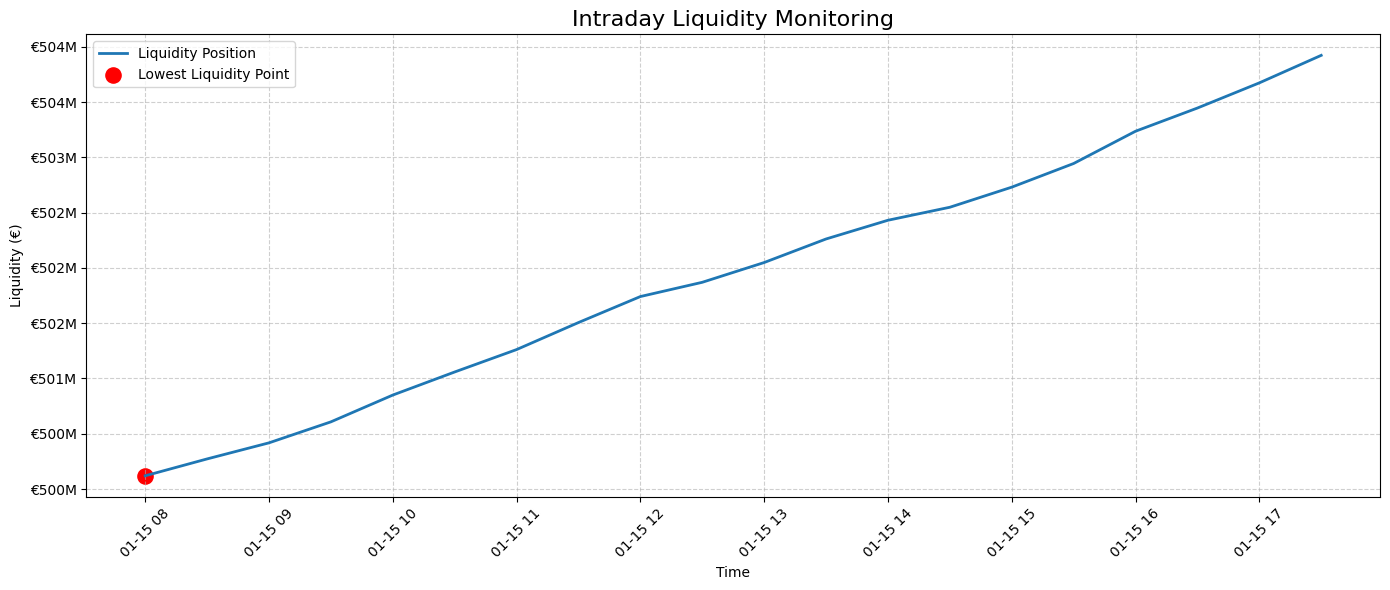

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    liquidity["time_bucket"],
    liquidity["liquidity_position"],
    linewidth=2,
    label="Liquidity Position"
)

plt.scatter(
    lowest_time,
    lowest_liquidity,
    color="red",
    s=120,
    label="Lowest Liquidity Point"
)

plt.title("Intraday Liquidity Monitoring", fontsize=16)
plt.xlabel("Time")
plt.ylabel("Liquidity (€)")

# Format y-axis in millions
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"€{x/1e6:.0f}M")
)

plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()

plt.show()

This chart shows the bank’s intraday liquidity position during the day. The bank begins with an opening liquidity buffer of approximately €500M. As payments are processed, liquidity changes depending on inflows and outflows. The red marker highlights the lowest liquidity level during the day, which is an important indicator of maximum liquidity usage. In this simulation liquidity gradually increases because inflows exceed outflows, indicating no liquidity stress during the day.